Loaded model from /kaggle/input/testig1/seizure_prediction_model.h5
Processing test file: /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb02/chb02_16+.edf
Extracting EDF parameters from /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb02/chb02_16+.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


<ipython-input-1-eb7ed6767ad6>:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
Successfully loaded file with 23 channels
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Filtering successful
Data shape: (23, 921600), Sampling rate: 256.0Hz
Creating 3599 windows of size 512 with step 256
Created 3599 windows with 41.0 seizure windows
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.92      0.96      3558
         1.0       0.05      0.34      0.08        41

    accuracy                           0.92      3599
   macro avg       0.52      0.63      0.52      3599
weighted avg       0.98      0.92      0.95      3599


Confusion Matrix:
[[3283  275]
 [  27   14]]

Sensitivity (Recall): 0.3415
Specificity: 0.9227
Precision: 0.0484
F1 Score: 0.0848


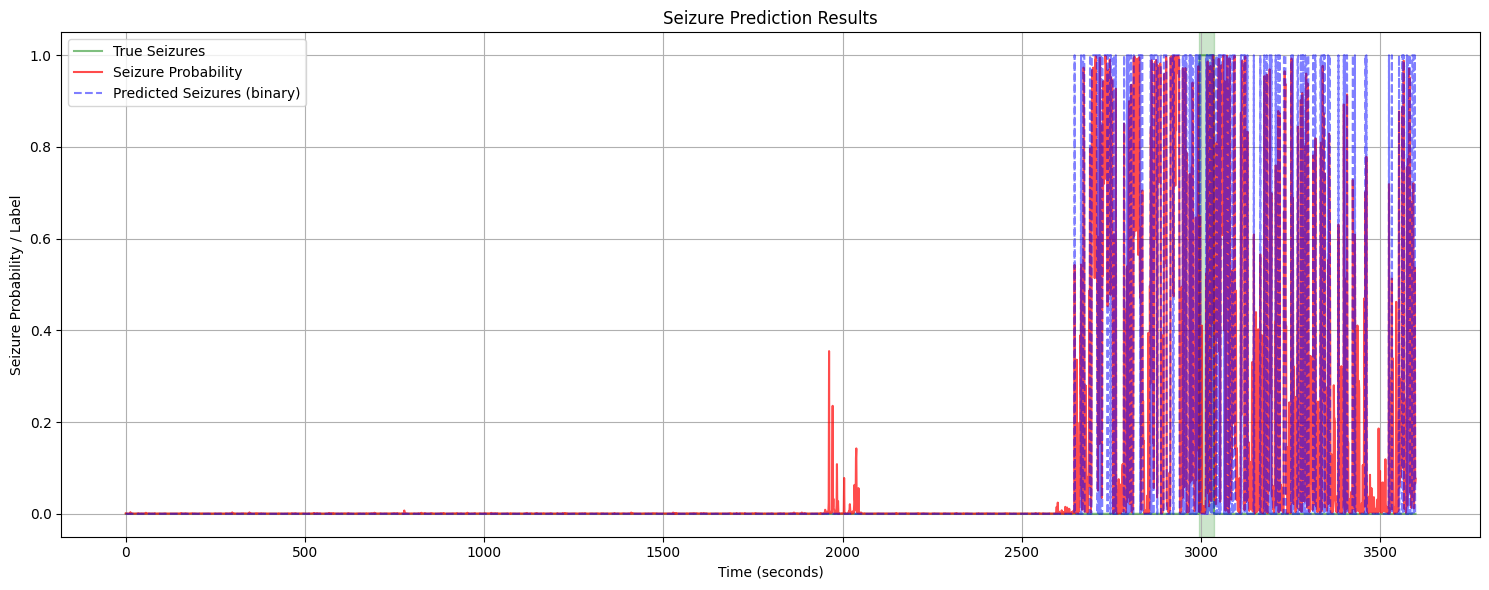

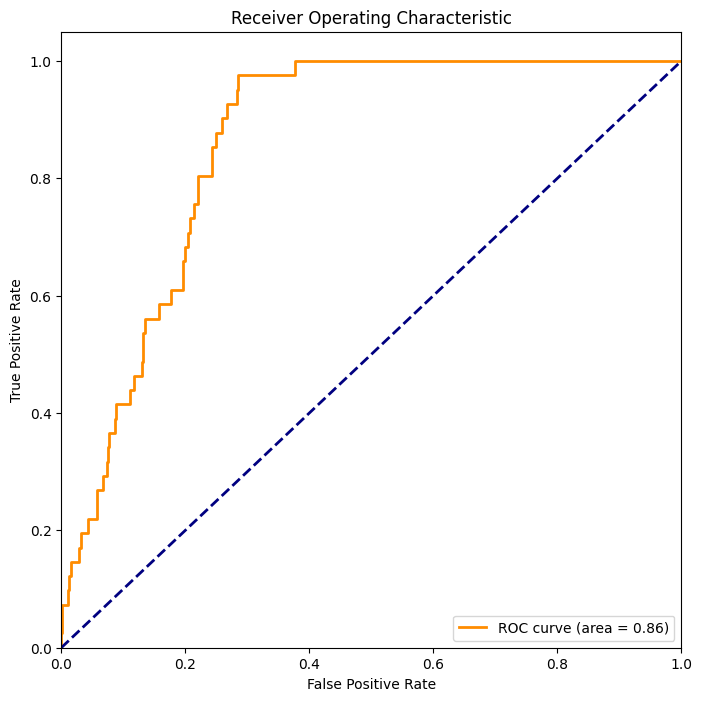


Seizure at 2996s predicted 299.00 seconds in advance


In [1]:
import os
import numpy as np
import mne
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

def process_test_file(edf_path, seizure_times, window_size_sec=2, overlap=0.5):
    print(f"Processing test file: {edf_path}")
    
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True)
        print(f"Successfully loaded file with {len(raw.ch_names)} channels")
    except Exception as e:
        print(f"Error loading EDF file: {e}")
        return None, None, None
    
    try:
        raw.filter(1.0, 40.0)
        print("Filtering successful")
    except Exception as e:
        print(f"Error filtering: {e}")
        return None, None, None
    
    data = raw.get_data()
    sfreq = raw.info['sfreq']
    print(f"Data shape: {data.shape}, Sampling rate: {sfreq}Hz")
    
    window_size = int(window_size_sec * sfreq)
    step = int(window_size * (1 - overlap))
    
    n_channels, n_samples = data.shape
    n_windows = (n_samples - window_size) // step + 1
    print(f"Creating {n_windows} windows of size {window_size} with step {step}")
    
    windows = np.zeros((n_windows, n_channels, window_size))
    labels = np.zeros(n_windows)
    timestamps = np.zeros(n_windows)
    
    for i in range(n_windows):
        start_sample = i * step
        end_sample = start_sample + window_size
        windows[i] = data[:, start_sample:end_sample]
        
        start_time = start_sample / sfreq
        timestamps[i] = start_time
        
        for seizure_start, seizure_end in seizure_times:
            if max(start_time, seizure_start) < min(start_time + window_size_sec, seizure_end):
                labels[i] = 1
                break
    
    print(f"Created {n_windows} windows with {np.sum(labels)} seizure windows")
    return windows, labels, timestamps

def normalize_windows(windows):
    """Normalize the windows for model input"""
    n_windows, n_channels, n_samples = windows.shape
    reshaped = windows.reshape(n_windows * n_channels, n_samples)
    
    scaler = StandardScaler()
    normalized = scaler.fit_transform(reshaped.T).T
    
    return normalized.reshape(n_windows, n_channels, n_samples)

def visualize_predictions(timestamps, true_labels, predictions, threshold=0.5):
    """Visualize the predictions against ground truth"""
    binary_preds = (predictions > threshold).astype(int)
    
    plt.figure(figsize=(15, 6))
    plt.plot(timestamps, true_labels, 'g-', label='True Seizures', alpha=0.5)
    plt.plot(timestamps, predictions, 'r-', label='Seizure Probability', alpha=0.7)
    plt.plot(timestamps, binary_preds, 'b--', label='Predicted Seizures (binary)', alpha=0.5)
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Seizure Probability / Label')
    plt.title('Seizure Prediction Results')
    plt.legend()
    plt.grid(True)
    
    seizure_starts = []
    for i in range(1, len(true_labels)):
        if true_labels[i] == 1 and true_labels[i-1] == 0:
            seizure_starts.append(timestamps[i])
    
    seizure_ends = []
    for i in range(1, len(true_labels)):
        if true_labels[i] == 0 and true_labels[i-1] == 1:
            seizure_ends.append(timestamps[i])
    
    if len(true_labels) > 0 and true_labels[-1] == 1:
        seizure_ends.append(timestamps[-1])
    
    for start, end in zip(seizure_starts, seizure_ends):
        plt.axvspan(start, end, color='green', alpha=0.2)
    
    plt.tight_layout()
    plt.show()
    
    fpr, tpr, thresholds = roc_curve(true_labels, predictions)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

if __name__ == "__main__":
    base_dir = "/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0"
    subject_dir = os.path.join(base_dir, "chb02")
    
    model_path = "/kaggle/input/testig1/seizure_prediction_model.h5"
    model = keras.models.load_model(model_path)
    print(f"Loaded model from {model_path}")
    
    test_file = "chb02_16+.edf" 
    seizure_times = [(2996, 3036)]
    
    test_path = os.path.join(subject_dir, test_file)
    windows, labels, timestamps = process_test_file(test_path, seizure_times)
    
    if windows is not None:
        normalized_windows = normalize_windows(windows)
        
        predictions = model.predict(normalized_windows)
        predictions = predictions.flatten()
        
        binary_preds = (predictions > 0.5).astype(int)
        
        print("\nClassification Report:")
        print(classification_report(labels, binary_preds))
        
        print("\nConfusion Matrix:")
        cm = confusion_matrix(labels, binary_preds)
        print(cm)
        
        tp = cm[1, 1]
        fp = cm[0, 1]
        tn = cm[0, 0]
        fn = cm[1, 0]
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        print(f"\nSensitivity (Recall): {sensitivity:.4f}")
        print(f"Specificity: {specificity:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"F1 Score: {2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0:.4f}")
        
        visualize_predictions(timestamps, labels, predictions)
        
        if np.sum(labels) > 0:
            for seizure_start, seizure_end in seizure_times:
                pre_seizure_indices = np.where((timestamps < seizure_start) & 
                                              (timestamps > seizure_start - 300))[0]  # Look at 5 minutes before
                
                if len(pre_seizure_indices) > 0:
                    pre_seizure_preds = predictions[pre_seizure_indices]
                    pre_seizure_times = timestamps[pre_seizure_indices]
                    
                    threshold = 0.7
                    early_detection_indices = np.where(pre_seizure_preds > threshold)[0]
                    
                    if len(early_detection_indices) > 0:
                        earliest_detection = pre_seizure_times[early_detection_indices[0]]
                        prediction_time = seizure_start - earliest_detection
                        print(f"\nSeizure at {seizure_start}s predicted {prediction_time:.2f} seconds in advance")
                    else:
                        print("\nNo early prediction for this seizure")
    else:
        print("Failed to process test file")


Extracting EDF parameters from /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


<ipython-input-2-cc8e52722c8f>:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_data = mne.io.read_raw_edf(edf_path, preload=True)


EEG Data Shape: (23, 921600)
Sampling Frequency: 256.0 Hz
Using matplotlib as 2D backend.


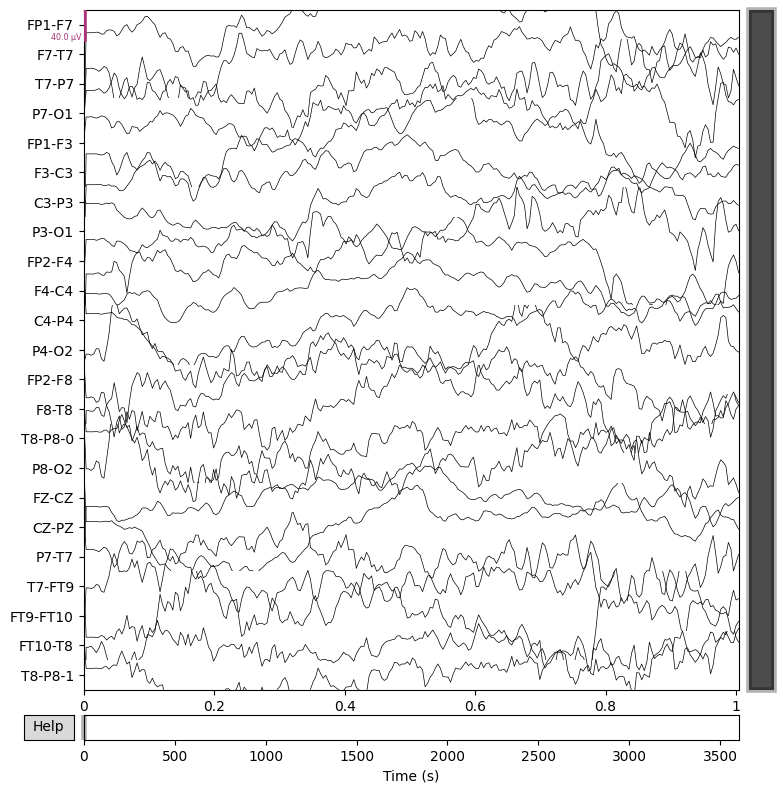

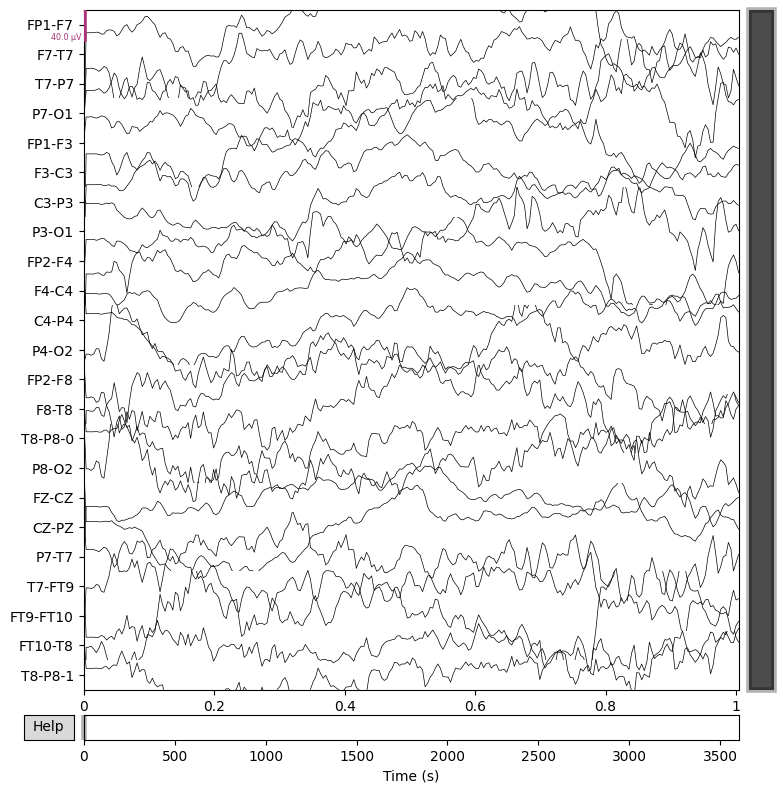

In [2]:
import mne
import numpy as np

# Load EDF file
edf_path = "/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_01.edf"
raw_data = mne.io.read_raw_edf(edf_path, preload=True)

# Extract EEG signals
eeg_data = raw_data.get_data()  # Shape: (channels, time points)
sampling_freq = raw_data.info['sfreq']  # Get sampling frequency

print(f"EEG Data Shape: {eeg_data.shape}")  # (channels, time_points)
print(f"Sampling Frequency: {sampling_freq} Hz")

raw_data.plot(duration=1, n_channels=23)



In [3]:
# Bandpass filter function
sampling_rate = 256
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut=0.5, highcut=50.0, fs=256, order=3):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data, axis=1)  # Filter along the time axis

# Apply the filter to EEG data
filtered_eeg = bandpass_filter(raw_data.get_data(), lowcut=0.5, highcut=50, fs=sampling_rate)


NameError: name 'butter' is not defined

In [ ]:
import os
import numpy as np
import mne
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import gc
import matplotlib.pyplot as plt

def process_single_file_in_batches(edf_path, seizure_times, window_size_sec=2, overlap=0.5, batch_size=100):
    """Process a single EDF file with known seizure times using batch processing"""
    print(f"Processing file: {edf_path}")
    
    # Load the raw EEG data
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True)
        print(f"Successfully loaded file with {len(raw.ch_names)} channels")
    except Exception as e:
        print(f"Error loading EDF file: {e}")
        return None, None, None
    
    # Apply basic filtering
    try:
        raw.filter(1.0, 40.0)
        print("Filtering successful")
    except Exception as e:
        print(f"Error filtering: {e}")
        return None, None, None
    
    # Get data parameters
    n_channels = len(raw.ch_names)
    n_samples = raw.n_times
    sfreq = raw.info['sfreq']
    print(f"Data shape: ({n_channels}, {n_samples}), Sampling rate: {sfreq}Hz")
    
    # Calculate window parameters
    window_size = int(window_size_sec * sfreq)
    step = int(window_size * (1 - overlap))
    n_windows = (n_samples - window_size) // step + 1
    print(f"Creating {n_windows} windows of size {window_size} with step {step}")
    
    # Process in batches
    all_windows = []
    all_labels = []
    
    for batch_start in range(0, n_windows, batch_size):
        batch_end = min(batch_start + batch_size, n_windows)
        print(f"Processing batch {batch_start//batch_size + 1}: windows {batch_start} to {batch_end-1}")
        
        batch_windows = []
        batch_labels = []
        
        for i in range(batch_start, batch_end):
            start_sample = i * step
            end_sample = start_sample + window_size
            
            # Extract this window's data
            window_data = raw.get_data(start=start_sample, stop=end_sample)
            batch_windows.append(window_data)
            
            # Calculate time in seconds for this window
            start_time = start_sample / sfreq
            end_time = end_sample / sfreq
            
            # Check if window overlaps with any seizure
            is_seizure = 0
            for seizure_start, seizure_end in seizure_times:
                if max(start_time, seizure_start) < min(end_time, seizure_end):
                    is_seizure = 1
                    break
            
            batch_labels.append(is_seizure)
        
        # Convert batch to numpy arrays
        batch_windows = np.array(batch_windows)
        batch_labels = np.array(batch_labels)
        
        # Store batch results
        all_windows.append(batch_windows)
        all_labels.append(batch_labels)
        
        print(f"Processed {len(batch_labels)} windows with {np.sum(batch_labels)} seizure windows")
    
    # Combine all batches
    windows = np.vstack(all_windows)
    labels = np.concatenate(all_labels)
    
    print(f"Created total of {len(labels)} windows with {np.sum(labels)} seizure windows")
    return windows, labels, sfreq

def normalize_in_batches(windows, batch_size=1000):
    """Normalize windows in batches to save memory"""
    n_windows, n_channels, n_samples = windows.shape
    normalized_windows = []
    
    for i in range(0, n_windows, batch_size):
        end_idx = min(i + batch_size, n_windows)
        batch = windows[i:end_idx]
        
        # Reshape for normalization
        batch_reshaped = batch.reshape((end_idx - i) * n_channels, n_samples)
        
        # Normalize
        scaler = StandardScaler()
        batch_normalized = scaler.fit_transform(batch_reshaped.T).T
        
        # Reshape back
        batch_normalized = batch_normalized.reshape(end_idx - i, n_channels, n_samples)
        normalized_windows.append(batch_normalized)
    
    # Combine normalized batches
    return np.vstack(normalized_windows)

def balance_dataset_in_batches(X, y, batch_size=1000):
    """Balance dataset in batches to handle class imbalance"""
    seizure_idx = np.where(y == 1)[0]
    non_seizure_idx = np.where(y == 0)[0]
    
    # Sample equal numbers from each class 
    n_samples = min(len(seizure_idx) * 10, len(non_seizure_idx))  # Cap non-seizure samples
    
    # Oversample seizures
    balanced_seizure_idx = np.repeat(seizure_idx, 10)[:n_samples]
    
    # Sample non-seizures
    balanced_non_seizure_idx = np.random.choice(non_seizure_idx, n_samples, replace=False)
    
    # Combine indices
    balanced_idx = np.concatenate([balanced_seizure_idx, balanced_non_seizure_idx])
    np.random.shuffle(balanced_idx)
    
    # Create balanced dataset in batches
    X_balanced = []
    y_balanced = []
    
    for i in range(0, len(balanced_idx), batch_size):
        end_idx = min(i + batch_size, len(balanced_idx))
        batch_idx = balanced_idx[i:end_idx]
        X_balanced.append(X[batch_idx])
        y_balanced.append(y[batch_idx])
    
    # Combine batches
    X_balanced_combined = np.vstack(X_balanced)
    y_balanced_combined = np.concatenate(y_balanced)
    
    # Free memory
    del X_balanced, y_balanced
    gc.collect()
    
    return X_balanced_combined, y_balanced_combined

def create_cnn_lstm_model(input_shape):
    """Create a CNN-LSTM model for seizure prediction"""
    model = keras.Sequential([
        # CNN layers
        keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        
        # Reshape for LSTM
        keras.layers.Reshape((-1, 64)),
        
        # LSTM layers
        keras.layers.LSTM(64, return_sequences=True),
        keras.layers.LSTM(32),
        
        # Output layers
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 
                 keras.metrics.Precision(), 
                 keras.metrics.Recall(),
                 keras.metrics.AUC()]
    )
    
    return model

def train_model_in_batches(model, X_train, y_train, X_val, y_val, batch_size=32, epochs=10):
    """Train model in batches with custom batch generation to save memory"""
    # Create data generators
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)
    
    # Callbacks
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    # Train the model
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=[early_stopping]
    )
    
    return model, history

def evaluate_model(model, X_test, y_test, batch_size=32):
    """Evaluate model on test data in batches"""
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)
    
    # Evaluate the model
    test_metrics = model.evaluate(test_dataset)
    
    # Get predictions
    y_pred_proba = model.predict(test_dataset)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    
    # Calculate metrics
    from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    
    return test_metrics, y_pred, y_pred_proba

def plot_training_history(history):
    """Plot training history"""
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == "_main_":
    # Define paths and seizure information
    subject_dir = "/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01"  # Replace with your actual path
    
    # Example seizure_info dictionary - replace with your actual seizure information
    # Format: {filename: [(seizure_start_time_sec, seizure_end_time_sec), ...]}
    seizure_info = {
        "patient1_seizure1.edf": [(120, 150), (300, 330)],
        "patient1_seizure2.edf": [(200, 240)],
        # Add more files as needed
    }
    
    # Process files one at a time to save memory
    all_windows = []
    all_labels = []
    
    for file_name, seizure_times in seizure_info.items():
        edf_path = os.path.join(subject_dir, file_name)
        
        if os.path.exists(edf_path):
            print(f"\nProcessing {file_name}...")
            windows, labels, file_sfreq = process_single_file_in_batches(edf_path, seizure_times)
            
            if windows is not None:
                # Process immediately to save memory
                print(f"Processing {windows.shape[0]} windows from this file")
                
                # Normalize windows
                normalized_windows = normalize_in_batches(windows)
                
                # Store normalized windows and labels
                all_windows.append(normalized_windows)
                all_labels.append(labels)
                
                # Free memory
                del windows, normalized_windows
                gc.collect()
                
                print(f"Processed and normalized windows from {file_name}")
        else:
            print(f"File not found: {edf_path}")
    
    # Process the combined dataset
    if all_windows:
        # Combine all windows and labels
        X = np.vstack(all_windows)
        y = np.concatenate(all_labels)
        
        # Free memory
        del all_windows, all_labels
        gc.collect()
        
        print("\nDataset summary:")
        print(f"Total windows: {len(y)}")
        print(f"Seizure windows: {np.sum(y)} ({np.sum(y)/len(y)*100:.2f}%)")
        print(f"Non-seizure windows: {len(y) - np.sum(y)} ({(len(y) - np.sum(y))/len(y)*100:.2f}%)")
        
        # Add channel dimension for CNN
        X = X[:, :, :, np.newaxis]  # For TensorFlow/Keras
        
        # Handle class imbalance if needed
        if np.sum(y) / len(y) < 0.1:  # If seizures are less than 10%
            print("Balancing dataset for model training...")
            X, y = balance_dataset_in_batches(X, y)
            print(f"Balanced dataset: {len(y)} samples with {np.sum(y)} seizure windows ({np.sum(y)/len(y)*100:.2f}%)")
        
        # Split into train/val/test
        X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)
        
        # Free memory
        del X, y, X_train_val, y_train_val
        gc.collect()
        
        print("\nSplit sizes:")
        print(f"Training: {X_train.shape[0]} samples")
        print(f"Validation: {X_val.shape[0]} samples")
        print(f"Testing: {X_test.shape[0]} samples")
        
        # Create and train the model
        input_shape = X_train.shape[1:]
        print(f"Input shape: {input_shape}")
        
        model = create_cnn_lstm_model(input_shape)
        print(model.summary())
        
        # Train the model
        batch_size = 32
        epochs = 20
        model, history = train_model_in_batches(model, X_train, y_train, X_val, y_val, batch_size, epochs)
        
        # Plot training history
        plot_training_history(history)
        
        # Evaluate the model
        test_metrics, y_pred, y_pred_proba = evaluate_model(model, X_test, y_test, batch_size)
        
        # Save the model
        model.save("seizure_prediction_model.h5")
        print("Model saved successfully")
        
    else:
        print("No data was processed successfully!")

In [ ]:
import mne
import numpy as np

In [ ]:
import os
import numpy as np
import mne
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import gc
import matplotlib.pyplot as plt

def process_single_file_in_batches(edf_path, seizure_times, window_size_sec=2, overlap=0.5, batch_size=100):
    """Process a single EDF file with known seizure times using batch processing"""
    print(f"Processing file: {edf_path}")
    
    # Load the raw EEG data
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True)
        print(f"Successfully loaded file with {len(raw.ch_names)} channels")
    except Exception as e:
        print(f"Error loading EDF file: {e}")
        return None, None, None
    
    # Apply basic filtering
    try:
        raw.filter(1.0, 40.0)
        print("Filtering successful")
    except Exception as e:
        print(f"Error filtering: {e}")
        return None, None, None
    
    # Get data parameters
    n_channels = len(raw.ch_names)
    n_samples = raw.n_times
    sfreq = raw.info['sfreq']
    print(f"Data shape: ({n_channels}, {n_samples}), Sampling rate: {sfreq}Hz")
    
    # Calculate window parameters
    window_size = int(window_size_sec * sfreq)
    step = int(window_size * (1 - overlap))
    n_windows = (n_samples - window_size) // step + 1
    print(f"Creating {n_windows} windows of size {window_size} with step {step}")
    
    # Process in batches
    all_windows = []
    all_labels = []
    
    for batch_start in range(0, n_windows, batch_size):
        batch_end = min(batch_start + batch_size, n_windows)
        print(f"Processing batch {batch_start//batch_size + 1}: windows {batch_start} to {batch_end-1}")
        
        batch_windows = []
        batch_labels = []
        
        for i in range(batch_start, batch_end):
            start_sample = i * step
            end_sample = start_sample + window_size
            
            # Extract this window's data
            window_data = raw.get_data(start=start_sample, stop=end_sample)
            batch_windows.append(window_data)
            
            # Calculate time in seconds for this window
            start_time = start_sample / sfreq
            end_time = end_sample / sfreq
            
            # Check if window overlaps with any seizure
            is_seizure = 0
            for seizure_start, seizure_end in seizure_times:
                if max(start_time, seizure_start) < min(end_time, seizure_end):
                    is_seizure = 1
                    break
            
            batch_labels.append(is_seizure)
        
        # Convert batch to numpy arrays
        batch_windows = np.array(batch_windows)
        batch_labels = np.array(batch_labels)
        
        # Store batch results
        all_windows.append(batch_windows)
        all_labels.append(batch_labels)
        
        print(f"Processed {len(batch_labels)} windows with {np.sum(batch_labels)} seizure windows")
    
    # Combine all batches
    windows = np.vstack(all_windows)
    labels = np.concatenate(all_labels)
    
    print(f"Created total of {len(labels)} windows with {np.sum(labels)} seizure windows")
    return windows, labels, sfreq

def normalize_in_batches(windows, batch_size=1000):
    """Normalize windows in batches to save memory"""
    n_windows, n_channels, n_samples = windows.shape
    normalized_windows = []
    
    for i in range(0, n_windows, batch_size):
        end_idx = min(i + batch_size, n_windows)
        batch = windows[i:end_idx]
        
        # Reshape for normalization
        batch_reshaped = batch.reshape((end_idx - i) * n_channels, n_samples)
        
        # Normalize
        scaler = StandardScaler()
        batch_normalized = scaler.fit_transform(batch_reshaped.T).T
        
        # Reshape back
        batch_normalized = batch_normalized.reshape(end_idx - i, n_channels, n_samples)
        normalized_windows.append(batch_normalized)
    
    # Combine normalized batches
    return np.vstack(normalized_windows)

def balance_dataset_in_batches(X, y, batch_size=1000):
    """Balance dataset in batches to handle class imbalance"""
    seizure_idx = np.where(y == 1)[0]
    non_seizure_idx = np.where(y == 0)[0]
    
    # Sample equal numbers from each class 
    n_samples = min(len(seizure_idx) * 10, len(non_seizure_idx))  # Cap non-seizure samples
    
    # Oversample seizures
    balanced_seizure_idx = np.repeat(seizure_idx, 10)[:n_samples]
    
    # Sample non-seizures
    balanced_non_seizure_idx = np.random.choice(non_seizure_idx, n_samples, replace=False)
    
    # Combine indices
    balanced_idx = np.concatenate([balanced_seizure_idx, balanced_non_seizure_idx])
    np.random.shuffle(balanced_idx)
    
    # Create balanced dataset in batches
    X_balanced = []
    y_balanced = []
    
    for i in range(0, len(balanced_idx), batch_size):
        end_idx = min(i + batch_size, len(balanced_idx))
        batch_idx = balanced_idx[i:end_idx]
        X_balanced.append(X[batch_idx])
        y_balanced.append(y[batch_idx])
    
    # Combine batches
    X_balanced_combined = np.vstack(X_balanced)
    y_balanced_combined = np.concatenate(y_balanced)
    
    # Free memory
    del X_balanced, y_balanced
    gc.collect()
    
    return X_balanced_combined, y_balanced_combined

def create_cnn_lstm_model(input_shape):
    """Create a CNN-LSTM model for seizure prediction"""
    model = keras.Sequential([
        # CNN layers
        keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        
        # Reshape for LSTM
        keras.layers.Reshape((-1, 64)),
        
        # LSTM layers
        keras.layers.LSTM(64, return_sequences=True),
        keras.layers.LSTM(32),
        
        # Output layers
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 
                 keras.metrics.Precision(), 
                 keras.metrics.Recall(),
                 keras.metrics.AUC()]
    )
    
    return model

def train_model_in_batches(model, X_train, y_train, X_val, y_val, batch_size=32, epochs=10):
    """Train model in batches with custom batch generation to save memory"""
    # Create data generators
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)
    
    # Callbacks
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    # Train the model
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=[early_stopping]
    )
    
    return model, history

def evaluate_model(model, X_test, y_test, batch_size=32):
    """Evaluate model on test data in batches"""
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)
    
    # Evaluate the model
    test_metrics = model.evaluate(test_dataset)
    
    # Get predictions
    y_pred_proba = model.predict(test_dataset)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    
    # Calculate metrics
    from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    
    return test_metrics, y_pred, y_pred_proba

def plot_training_history(history):
    """Plot training history"""
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Main execution
if _name_ == "_main_":
    # Define paths and seizure information
    subject_dir = "/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01"  # Replace with your actual path
    
    # Example seizure_info dictionary - replace with your actual seizure information
    # Format: {filename: [(seizure_start_time_sec, seizure_end_time_sec), ...]}
    seizure_info = {
        "patient1_seizure1.edf": [(120, 150), (300, 330)],
        "patient1_seizure2.edf": [(200, 240)],
        # Add more files as needed
    }
    
    # Process files one at a time to save memory
    all_windows = []
    all_labels = []
    
    for file_name, seizure_times in seizure_info.items():
        edf_path = os.path.join(subject_dir, file_name)
        
        if os.path.exists(edf_path):
            print(f"\nProcessing {file_name}...")
            windows, labels, file_sfreq = process_single_file_in_batches(edf_path, seizure_times)
            
            if windows is not None:
                # Process immediately to save memory
                print(f"Processing {windows.shape[0]} windows from this file")
                
                # Normalize windows
                normalized_windows = normalize_in_batches(windows)
                
                # Store normalized windows and labels
                all_windows.append(normalized_windows)
                all_labels.append(labels)
                
                # Free memory
                del windows, normalized_windows
                gc.collect()
                
                print(f"Processed and normalized windows from {file_name}")
        else:
            print(f"File not found: {edf_path}")
    
    # Process the combined dataset
    if all_windows:
        # Combine all windows and labels
        X = np.vstack(all_windows)
        y = np.concatenate(all_labels)
        
        # Free memory
        del all_windows, all_labels
        gc.collect()
        
        print("\nDataset summary:")
        print(f"Total windows: {len(y)}")
        print(f"Seizure windows: {np.sum(y)} ({np.sum(y)/len(y)*100:.2f}%)")
        print(f"Non-seizure windows: {len(y) - np.sum(y)} ({(len(y) - np.sum(y))/len(y)*100:.2f}%)")
        
        # Add channel dimension for CNN
        X = X[:, :, :, np.newaxis]  # For TensorFlow/Keras
        
        # Handle class imbalance if needed
        if np.sum(y) / len(y) < 0.1:  # If seizures are less than 10%
            print("Balancing dataset for model training...")
            X, y = balance_dataset_in_batches(X, y)
            print(f"Balanced dataset: {len(y)} samples with {np.sum(y)} seizure windows ({np.sum(y)/len(y)*100:.2f}%)")
        
        # Split into train/val/test
        X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)
        
        # Free memory
        del X, y, X_train_val, y_train_val
        gc.collect()
        
        print("\nSplit sizes:")
        print(f"Training: {X_train.shape[0]} samples")
        print(f"Validation: {X_val.shape[0]} samples")
        print(f"Testing: {X_test.shape[0]} samples")
        
        # Create and train the model
        input_shape = X_train.shape[1:]
        print(f"Input shape: {input_shape}")
        
        model = create_cnn_lstm_model(input_shape)
        print(model.summary())
        
        # Train the model
        batch_size = 32
        epochs = 20
        model, history = train_model_in_batches(model, X_train, y_train, X_val, y_val, batch_size, epochs)
        
        # Plot training history
        plot_training_history(history)
        
        # Evaluate the model
        test_metrics, y_pred, y_pred_proba = evaluate_model(model, X_test, y_test, batch_size)
        
        # Save the model
        model.save("seizure_prediction_model.h5")
        print("Model saved successfully")
        
    else:
        print("No data was processed successfully!")

In [ ]:
import os
import numpy as np
import mne
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import gc
import psutil

# Configuration
BASE_DIR = "/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0"
PATIENT_ID = "chb01"
WINDOW_SIZE_SEC = 2
OVERLAP = 0.5
BATCH_SIZE = 64
MAX_SAMPLES_PER_FILE = 1000

def print_memory():
    print(f"Memory usage: {psutil.Process().memory_info().rss/1024**3:.2f} GB")

def parse_seizure_summary(summary_file):
    seizure_info = {}
    current_file = None
    with open(summary_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith("File Name:"):
                current_file = line.split(": ")[1].strip()
                seizure_info[current_file] = []
            elif line.startswith("Seizure Start Time:"):
                start = int(line.split(": ")[1].split()[0])
                next_line = next(f).strip()
                if "Seizure End Time:" in next_line:
                    end = int(next_line.split(": ")[1].split()[0])
                    seizure_info[current_file].append((start, end))
    return seizure_info

def process_file(edf_path, seizure_times):
    try:
        # Load with preload=True and handle duplicates
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        # Explicitly rename duplicate channels
        raw.rename_channels(lambda name: f"{name}_{raw.ch_names.index(name)}")
        raw.filter(1., 40., fir_design='firwin')
    except Exception as e:
        print(f"Error processing {edf_path}: {str(e)}")
        return None, None

    sfreq = raw.info['sfreq']
    window_size = int(WINDOW_SIZE_SEC * sfreq)
    step = int(window_size * (1 - OVERLAP))
    
    windows = []
    labels = []
    
    # Process in chunks to control memory
    for i in range(0, len(raw), MAX_SAMPLES_PER_FILE):
        data, _ = raw[:, i:i+MAX_SAMPLES_PER_FILE]
        data = data.astype('float32')
        
        # Create windows
        for j in range(0, data.shape[1] - window_size, step):
            window = data[:, j:j+window_size]
            window_time = (i + j) / sfreq
            
            label = 0
            for start, end in seizure_times:
                if (start - 300) <= window_time < end:
                    label = 1
                    break
            
            windows.append(window.T)  # Transpose for channel last format
            labels.append(label)
            
            if len(windows) >= MAX_SAMPLES_PER_FILE:
                break
                
        # Memory cleanup
        del data
        gc.collect()
        
    return np.array(windows), np.array(labels)

def create_cnn_lstm_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # Temporal CNN
        layers.Conv1D(32, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.BatchNormalization(),
        
        # Spatial CNN
        layers.Reshape((-1, input_shape[0]//2, 32)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.GlobalAveragePooling2D(),
        
        # LSTM
        layers.Reshape((-1, 64)),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        
        # Classification
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

def train_patient(patient_id):
    patient_path = os.path.join(BASE_DIR, patient_id)
    summary_file = os.path.join(patient_path, f"{patient_id}-summary.txt")
    
    if not os.path.exists(summary_file):
        print(f"Missing summary for {patient_id}")
        return
    
    seizure_info = parse_seizure_summary(summary_file)
    if not seizure_info:
        print(f"No seizures found for {patient_id}")
        return
    
    # Initialize model
    model = None
    model_path = f"{patient_id}_model.keras"
    
    for file_idx, (file_name, seizures) in enumerate(seizure_info.items()):
        edf_path = os.path.join(patient_path, file_name)
        if not os.path.exists(edf_path):
            continue
            
        print(f"Processing {file_name} ({file_idx+1}/{len(seizure_info)})")
        print_memory()
        
        # Process file
        X, y = process_file(edf_path, seizures)
        if X is None or len(X) == 0:
            continue
            
        # Normalize
        X = StandardScaler().fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
        
        # Initialize model with first file's shape
        if model is None:
            model = create_cnn_lstm_model(X.shape[1:])
            model.summary()
            
        # Train incrementally
        model.fit(X, y,
                 epochs=2,
                 batch_size=BATCH_SIZE,
                 validation_split=0.2,
                 callbacks=[
                     callbacks.ModelCheckpoint(model_path),
                     callbacks.EarlyStopping(patience=2)
                 ])
        
        # Memory cleanup
        del X, y
        gc.collect()
        
    print(f"Training complete for {patient_id}. Model saved to {model_path}")

if __name__ == "__main__":
    train_patient(PATIENT_ID)


In [ ]:
import os
import numpy as np
import mne
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import gc
import matplotlib.pyplot as plt

def process_single_file_in_batches(edf_path, seizure_times, window_size_sec=2, overlap=0.5, batch_size=100):
    """Process a single EDF file with known seizure times using batch processing"""
    print(f"Processing file: {edf_path}")
    
    # Load the raw EEG data
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True)
        print(f"Successfully loaded file with {len(raw.ch_names)} channels")
    except Exception as e:
        print(f"Error loading EDF file: {e}")
        return None, None, None
    
    # Apply basic filtering
    try:
        raw.filter(1.0, 40.0)
        print("Filtering successful")
    except Exception as e:
        print(f"Error filtering: {e}")
        return None, None, None
    
    # Get data parameters
    n_channels = len(raw.ch_names)
    n_samples = raw.n_times
    sfreq = raw.info['sfreq']
    print(f"Data shape: ({n_channels}, {n_samples}), Sampling rate: {sfreq}Hz")
    
    # Calculate window parameters
    window_size = int(window_size_sec * sfreq)
    step = int(window_size * (1 - overlap))
    n_windows = (n_samples - window_size) // step + 1
    print(f"Creating {n_windows} windows of size {window_size} with step {step}")
    
    # Process in batches
    all_windows = []
    all_labels = []
    
    for batch_start in range(0, n_windows, batch_size):
        batch_end = min(batch_start + batch_size, n_windows)
        print(f"Processing batch {batch_start//batch_size + 1}: windows {batch_start} to {batch_end-1}")
        
        batch_windows = []
        batch_labels = []
        
        for i in range(batch_start, batch_end):
            start_sample = i * step
            end_sample = start_sample + window_size
            
            # Extract this window's data
            window_data = raw.get_data(start=start_sample, stop=end_sample)
            batch_windows.append(window_data)
            
            # Calculate time in seconds for this window
            start_time = start_sample / sfreq
            end_time = end_sample / sfreq
            
            # Check if window overlaps with any seizure
            is_seizure = 0
            for seizure_start, seizure_end in seizure_times:
                if max(start_time, seizure_start) < min(end_time, seizure_end):
                    is_seizure = 1
                    break
            
            batch_labels.append(is_seizure)
        
        # Convert batch to numpy arrays
        batch_windows = np.array(batch_windows)
        batch_labels = np.array(batch_labels)
        
        # Store batch results
        all_windows.append(batch_windows)
        all_labels.append(batch_labels)
        
        print(f"Processed {len(batch_labels)} windows with {np.sum(batch_labels)} seizure windows")
    
    # Combine all batches
    windows = np.vstack(all_windows)
    labels = np.concatenate(all_labels)
    
    print(f"Created total of {len(labels)} windows with {np.sum(labels)} seizure windows")
    return windows, labels, sfreq

def normalize_in_batches(windows, batch_size=1000):
    """Normalize windows in batches to save memory"""
    n_windows, n_channels, n_samples = windows.shape
    normalized_windows = []
    
    for i in range(0, n_windows, batch_size):
        end_idx = min(i + batch_size, n_windows)
        batch = windows[i:end_idx]
        
        # Reshape for normalization
        batch_reshaped = batch.reshape((end_idx - i) * n_channels, n_samples)
        
        # Normalize
        scaler = StandardScaler()
        batch_normalized = scaler.fit_transform(batch_reshaped.T).T
        
        # Reshape back
        batch_normalized = batch_normalized.reshape(end_idx - i, n_channels, n_samples)
        normalized_windows.append(batch_normalized)
    
    # Combine normalized batches
    return np.vstack(normalized_windows)

def balance_dataset_in_batches(X, y, batch_size=1000):
    """Balance dataset in batches to handle class imbalance"""
    seizure_idx = np.where(y == 1)[0]
    non_seizure_idx = np.where(y == 0)[0]
    
    # Sample equal numbers from each class 
    n_samples = min(len(seizure_idx) * 10, len(non_seizure_idx))  # Cap non-seizure samples
    
    # Oversample seizures
    balanced_seizure_idx = np.repeat(seizure_idx, 10)[:n_samples]
    
    # Sample non-seizures
    balanced_non_seizure_idx = np.random.choice(non_seizure_idx, n_samples, replace=False)
    
    # Combine indices
    balanced_idx = np.concatenate([balanced_seizure_idx, balanced_non_seizure_idx])
    np.random.shuffle(balanced_idx)
    
    # Create balanced dataset in batches
    X_balanced = []
    y_balanced = []
    
    for i in range(0, len(balanced_idx), batch_size):
        end_idx = min(i + batch_size, len(balanced_idx))
        batch_idx = balanced_idx[i:end_idx]
        X_balanced.append(X[batch_idx])
        y_balanced.append(y[batch_idx])
    
    # Combine batches
    X_balanced_combined = np.vstack(X_balanced)
    y_balanced_combined = np.concatenate(y_balanced)
    
    # Free memory
    del X_balanced, y_balanced
    gc.collect()
    
    return X_balanced_combined, y_balanced_combined

def create_cnn_lstm_model(input_shape):
    """Create a CNN-LSTM model for seizure prediction"""
    model = keras.Sequential([
        # CNN layers
        keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        
        # Reshape for LSTM
        keras.layers.Reshape((-1, 64)),
        
        # LSTM layers
        keras.layers.LSTM(64, return_sequences=True),
        keras.layers.LSTM(32),
        
        # Output layers
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 
                 keras.metrics.Precision(), 
                 keras.metrics.Recall(),
                 keras.metrics.AUC()]
    )
    
    return model

def train_model_in_batches(model, X_train, y_train, X_val, y_val, batch_size=32, epochs=10):
    """Train model in batches with custom batch generation to save memory"""
    # Create data generators
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)
    
    # Callbacks
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    # Train the model
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=[early_stopping]
    )
    
    return model, history

def evaluate_model(model, X_test, y_test, batch_size=32):
    """Evaluate model on test data in batches"""
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)
    
    # Evaluate the model
    test_metrics = model.evaluate(test_dataset)
    
    # Get predictions
    y_pred_proba = model.predict(test_dataset)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    
    # Calculate metrics
    from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    
    return test_metrics, y_pred, y_pred_proba

def plot_training_history(history):
    """Plot training history"""
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == "__main__":
    # Define paths and seizure information
    subject_dir = "path/to/edf/files"  # Replace with your actual path
    
    # Example seizure_info dictionary - replace with your actual seizure information
    # Format: {filename: [(seizure_start_time_sec, seizure_end_time_sec), ...]}
    seizure_info = {
        "patient1_seizure1.edf": [(120, 150), (300, 330)],
        "patient1_seizure2.edf": [(200, 240)],
        # Add more files as needed
    }
    
    # Process files one at a time to save memory
    all_windows = []
    all_labels = []
    
    for file_name, seizure_times in seizure_info.items():
        edf_path = os.path.join(subject_dir, file_name)
        
        if os.path.exists(edf_path):
            print(f"\nProcessing {file_name}...")
            windows, labels, file_sfreq = process_single_file_in_batches(edf_path, seizure_times)
            
            if windows is not None:
                # Process immediately to save memory
                print(f"Processing {windows.shape[0]} windows from this file")
                
                # Normalize windows
                normalized_windows = normalize_in_batches(windows)
                
                # Store normalized windows and labels
                all_windows.append(normalized_windows)
                all_labels.append(labels)
                
                # Free memory
                del windows, normalized_windows
                gc.collect()
                
                print(f"Processed and normalized windows from {file_name}")
        else:
            print(f"File not found: {edf_path}")
    
    # Process the combined dataset
    if all_windows:
        # Combine all windows and labels
        X = np.vstack(all_windows)
        y = np.concatenate(all_labels)
        
        # Free memory
        del all_windows, all_labels
        gc.collect()
        
        print("\nDataset summary:")
        print(f"Total windows: {len(y)}")
        print(f"Seizure windows: {np.sum(y)} ({np.sum(y)/len(y)*100:.2f}%)")
        print(f"Non-seizure windows: {len(y) - np.sum(y)} ({(len(y) - np.sum(y))/len(y)*100:.2f}%)")
        
        # Add channel dimension for CNN
        X = X[:, :, :, np.newaxis]  # For TensorFlow/Keras
        
        # Handle class imbalance if needed
        if np.sum(y) / len(y) < 0.1:  # If seizures are less than 10%
            print("Balancing dataset for model training...")
            X, y = balance_dataset_in_batches(X, y)
            print(f"Balanced dataset: {len(y)} samples with {np.sum(y)} seizure windows ({np.sum(y)/len(y)*100:.2f}%)")
        
        # Split into train/val/test
        X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)
        
        # Free memory
        del X, y, X_train_val, y_train_val
        gc.collect()
        
        print("\nSplit sizes:")
        print(f"Training: {X_train.shape[0]} samples")
        print(f"Validation: {X_val.shape[0]} samples")
        print(f"Testing: {X_test.shape[0]} samples")
        
        # Create and train the model
        input_shape = X_train.shape[1:]
        print(f"Input shape: {input_shape}")
        
        model = create_cnn_lstm_model(input_shape)
        print(model.summary())
        
        # Train the model
        batch_size = 32
        epochs = 20
        model, history = train_model_in_batches(model, X_train, y_train, X_val, y_val, batch_size, epochs)
        
        # Plot training history
        plot_training_history(history)
        
        # Evaluate the model
        test_metrics, y_pred, y_pred_proba = evaluate_model(model, X_test, y_test, batch_size)
        
        # Save the model
        model.save("seizure_prediction_model.h5")
        print("Model saved successfully")
        
    else:
        print("No data was processed successfully!")
